2.3 Feature Selection 

Feature Importance (Random Forest)

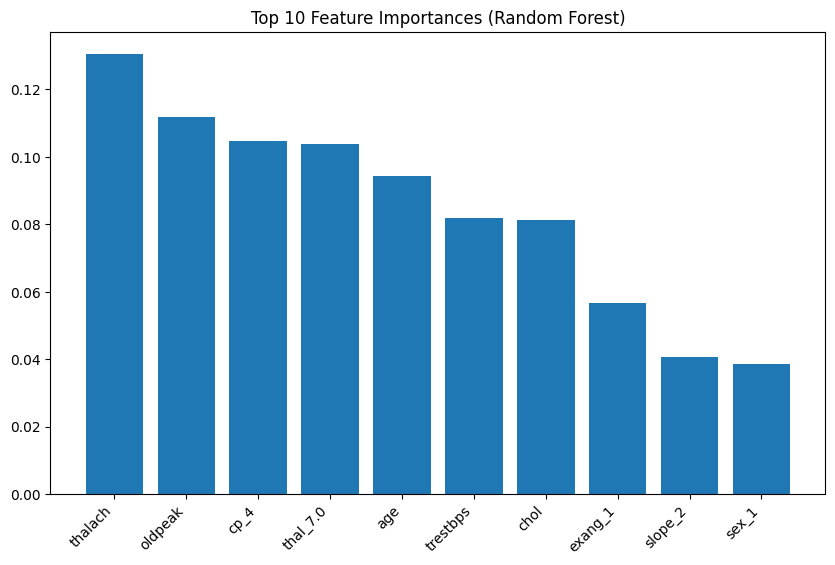

1. thalach: 0.1305
2. oldpeak: 0.1119
3. cp_4: 0.1046
4. thal_7.0: 0.1037
5. age: 0.0944
6. trestbps: 0.0819
7. chol: 0.0813
8. exang_1: 0.0565
9. slope_2: 0.0407
10. sex_1: 0.0384


In [ ]:
from sklearn.ensemble import RandomForestClassifier
# Train a simple Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_final, y_final)

# Get feature importances
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(10,6))
plt.bar(range(10), importances[indices[:10]], align="center")
plt.xticks(range(10), X_final.columns[indices[:10]], rotation=45, ha="right")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.show()

# Print ranking
for i in range(10):
    print(f"{i+1}. {X_final.columns[indices[i]]}: {importances[indices[i]]:.4f}")

Recursive Feature Elimination (RFE)

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

# Logistic Regression as estimator
logreg = LogisticRegression(max_iter=1000, solver="liblinear")

# RFE to pick top 10 features
selector = RFE(logreg, n_features_to_select=10)
selector.fit(X_final, y_final)

print("Selected Features (RFE):")
print(X_final.columns[selector.support_].tolist())


Selected Features (RFE):
['oldpeak', 'sex_1', 'cp_3', 'cp_4', 'exang_1', 'slope_2', 'ca_1.0', 'ca_2.0', 'ca_3.0', 'thal_7.0']


Chi-Square Test

In [ ]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler

# Scale to [0,1] for chi2
scaler = MinMaxScaler()
X_minmax = scaler.fit_transform(X_final)

chi2_selector = SelectKBest(chi2, k=10)
chi2_selector.fit(X_minmax, y_final)

print("Top 10 Features (Chi-Square):")
print(X_final.columns[chi2_selector.get_support()].tolist())


Top 10 Features (Chi-Square):
['oldpeak', 'cp_2', 'cp_3', 'cp_4', 'exang_1', 'slope_2', 'ca_1.0', 'ca_2.0', 'ca_3.0', 'thal_7.0']


Reduced dataset: Keep only selected features

In [ ]:
# ✅ Final selected features (union of RFE/Chi2 + strong numeric from RF)
selected_features = [
    'oldpeak', 'cp_3', 'cp_4', 'exang_1', 'slope_2',
    'ca_1.0', 'ca_2.0', 'ca_3.0', 'thal_7.0',
    'thalach', 'age'
]

# Reduce dataset
X_reduced = X_final[selected_features]
y_reduced = y_final   # target stays the same

print("Reduced dataset shape:", X_reduced.shape)
print("Features used:", list(X_reduced.columns))


Reduced dataset shape: (297, 11)
Features used: ['oldpeak', 'cp_3', 'cp_4', 'exang_1', 'slope_2', 'ca_1.0', 'ca_2.0', 'ca_3.0', 'thal_7.0', 'thalach', 'age']
